In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
alpha=0
fref=25
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                      fref=fref,alpha=alpha)

stochastic: Done with Interval 1 / 95
	Y     = 7.208608e-10
	sigma = 1.265302e-08
	SNR   = 0.056971
stochastic: Done with Interval 2 / 95
	Y     = -1.875900e-09
	sigma = 1.055885e-08
	SNR   = -0.177661
stochastic: Done with Interval 3 / 95
	Y     = 7.559280e-09
	sigma = 1.026376e-08
	SNR   = 0.736502
stochastic: Done with Interval 4 / 95
	Y     = 1.028121e-08
	sigma = 1.093756e-08
	SNR   = 0.939991


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2071378009.py:106: RuntimeWarning: divide by zero encountered in power
  (P1.freqs/fref)**(alpha-3)) )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2071378009.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data[1:],var_f.data[1:])
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2071378009.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data


stochastic: Done with Interval 5 / 95
	Y     = -1.079127e-08
	sigma = 1.052355e-08
	SNR   = -1.025441
stochastic: Done with Interval 6 / 95
	Y     = 4.822783e-09
	sigma = 1.020440e-08
	SNR   = 0.472618
stochastic: Done with Interval 7 / 95
	Y     = -4.793038e-09
	sigma = 1.118176e-08
	SNR   = -0.428648
stochastic: Done with Interval 8 / 95
	Y     = 1.995225e-08
	sigma = 1.205299e-08
	SNR   = 1.655377
stochastic: Done with Interval 9 / 95
	Y     = 1.480667e-09
	sigma = 1.211048e-08
	SNR   = 0.122263
stochastic: Done with Interval 10 / 95
	Y     = 2.382271e-09
	sigma = 1.099737e-08
	SNR   = 0.216622
stochastic: Done with Interval 11 / 95
	Y     = -8.651292e-09
	sigma = 1.148060e-08
	SNR   = -0.753557
stochastic: Done with Interval 12 / 95
	Y     = 1.904998e-08
	sigma = 1.346015e-08
	SNR   = 1.415288
stochastic: Done with Interval 13 / 95
	Y     = 1.051235e-08
	sigma = 1.374857e-08
	SNR   = 0.764614
stochastic: Done with Interval 14 / 95
	Y     = 7.980146e-09
	sigma = 1.160792e-08
	SNR   

stochastic: Done with Interval 85 / 95
	Y     = 1.346679e-08
	sigma = 1.152818e-08
	SNR   = 1.168163
stochastic: Done with Interval 86 / 95
	Y     = 1.187866e-09
	sigma = 1.078327e-08
	SNR   = 0.110158
stochastic: Done with Interval 87 / 95
	Y     = 2.493963e-09
	sigma = 1.057372e-08
	SNR   = 0.235864
stochastic: Done with Interval 88 / 95
	Y     = -5.289008e-11
	sigma = 1.151657e-08
	SNR   = -0.004593
stochastic: Done with Interval 89 / 95
	Y     = 2.232616e-08
	sigma = 1.161219e-08
	SNR   = 1.922649
stochastic: Done with Interval 90 / 95
	Y     = 1.938033e-08
	sigma = 1.185592e-08
	SNR   = 1.634655
stochastic: Done with Interval 91 / 95
	Y     = -4.224091e-09
	sigma = 1.099283e-08
	SNR   = -0.384259
stochastic: Done with Interval 92 / 95
	Y     = 9.749524e-09
	sigma = 1.036194e-08
	SNR   = 0.940898
stochastic: Done with Interval 93 / 95
	Y     = -1.683686e-08
	sigma = 1.079217e-08
	SNR   = -1.560099
stochastic: Done with Interval 94 / 95
	Y     = 7.716727e-09
	sigma = 1.249745e-08
	S

In [6]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2966287306.py:14: RuntimeWarning: invalid value encountered in divide
  Y_f_o = np.sum(Y_fs_odds / var_fs_odds,axis=1) / np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2966287306.py:15: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1/np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2966287306.py:17: RuntimeWarning: invalid value encountered in divide
  Y_f_e = np.sum(Y_fs_evens / var_fs_evens,axis=1) / np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2966287306.py:18: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1/np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_86772/2966287306.py:28: RuntimeWarning: invalid value encountered in subtract
  detC_f = C_f_oo*C_f_ee - C_f_oe**2
/var/folders/h9/8jj76gb51nq2gjkzk76xh3

11:17 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
11:17 bilby INFO    : Analysis priors:
11:17 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
11:17 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
11:17 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
11:17 bilby INFO    : Analysis likelihood noise evidence: -1912.9996863123902
11:17 bilby INFO    : Single likelihood evaluation took 4.418e-05 s
11:17 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

4523it [00:04, 788.47it/s, bound:101 nc: 16 ncall:7.8e+04 eff:5.8% logz-ratio=151.61+/-nan dlogz:0.117>0.1]        

11:17 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4599it [00:06, 719.56it/s, bound:103 nc:  1 ncall:8.0e+04 eff:6.4% logz-ratio=151.72+/-0.11 dlogz:0.000>0.1]

11:17 bilby INFO    : Rejection sampling nested samples to obtain 1270 posterior samples
11:17 bilby INFO    : Sampling time: 0:00:06.389945
11:17 bilby ERROR   : 

Saving the data has failed with the following message:
module 'numpy' has no attribute 'in1d'
Data has been dumped to outdir/GWB_powerlaw_result.pkl.


11:17 bilby ERROR   : 

Saving the data has failed with the following message:
module 'numpy' has no attribute 'in1d'
Data has been dumped to outdir/GWB_powerlaw_result.pkl.


11:17 bilby INFO    : Summary of results:
nsamples: 1270
ln_noise_evidence: -1913.000
ln_evidence: -1761.276 +/-  0.136
ln_bayes_factor: 151.724 +/-  0.136



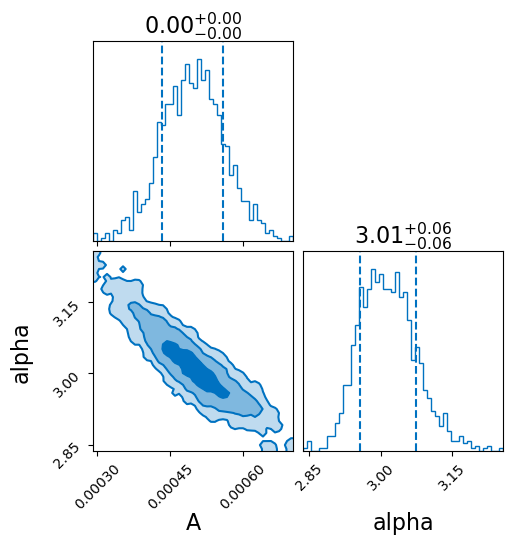

In [8]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],var_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [9]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

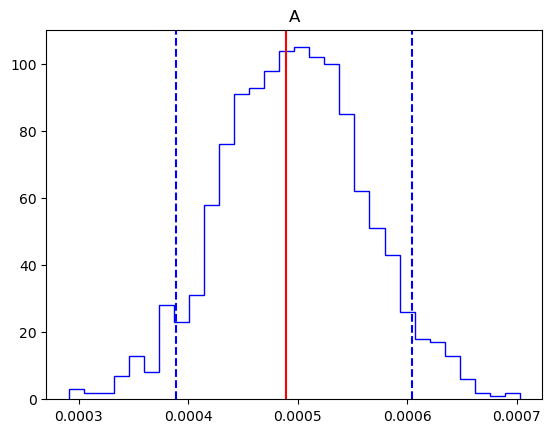

In [10]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red')

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

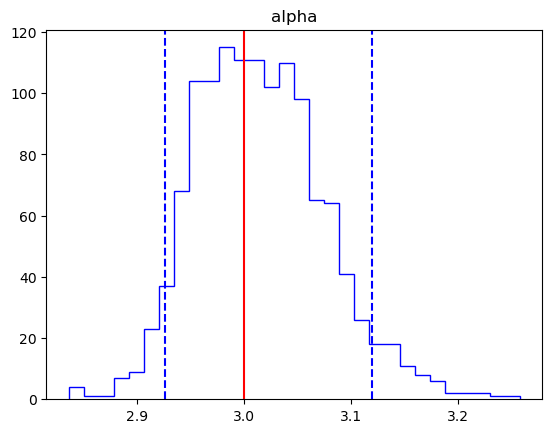

In [11]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')

11:17 bilby INFO    : Running for label 'GWB_brokenpowerlaw', output will be saved to 'outdir'
11:17 bilby INFO    : Analysis priors:
11:17 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
11:17 bilby INFO    : alpha1=Uniform(minimum=-5, maximum=5, name='alpha1', latex_label='alpha1', unit=None, boundary=None)
11:17 bilby INFO    : alpha2=Uniform(minimum=-5, maximum=5, name='alpha2', latex_label='alpha2', unit=None, boundary=None)
11:17 bilby INFO    : fbreak=Uniform(minimum=30, maximum=100, name='fbreak', latex_label='fbreak', unit=None, boundary=None)
11:17 bilby INFO    : Analysis likelihood class: <class '__main__.BrokenPowerLawGWBLikelihood'>
11:17 bilby INFO    : Analysis likelihood noise evidence: -1912.9996863123902
11:17 bilby INFO    : Single likelihood evaluation took 6.256e-05 s
11:17 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflectiv

6091it [00:22, 262.12it/s, bound:407 nc:  1 ncall:2.8e+05 eff:2.3% logz-ratio=148.77+/-0.13 dlogz:0.027>0.1]     

11:17 bilby INFO    : Written checkpoint file outdir/GWB_brokenpowerlaw_resume.pickle


6091it [00:24, 252.75it/s, bound:407 nc:  1 ncall:2.8e+05 eff:2.3% logz-ratio=148.79+/-0.13 dlogz:0.000>0.1]

11:17 bilby INFO    : Rejection sampling nested samples to obtain 1636 posterior samples
11:17 bilby INFO    : Sampling time: 0:00:24.095067
11:17 bilby ERROR   : 

Saving the data has failed with the following message:
module 'numpy' has no attribute 'in1d'
Data has been dumped to outdir/GWB_brokenpowerlaw_result.pkl.


11:17 bilby ERROR   : 

Saving the data has failed with the following message:
module 'numpy' has no attribute 'in1d'
Data has been dumped to outdir/GWB_brokenpowerlaw_result.pkl.


11:17 bilby INFO    : Summary of results:
nsamples: 1636
ln_noise_evidence: -1913.000
ln_evidence: -1764.209 +/-  0.160
ln_bayes_factor: 148.791 +/-  0.160



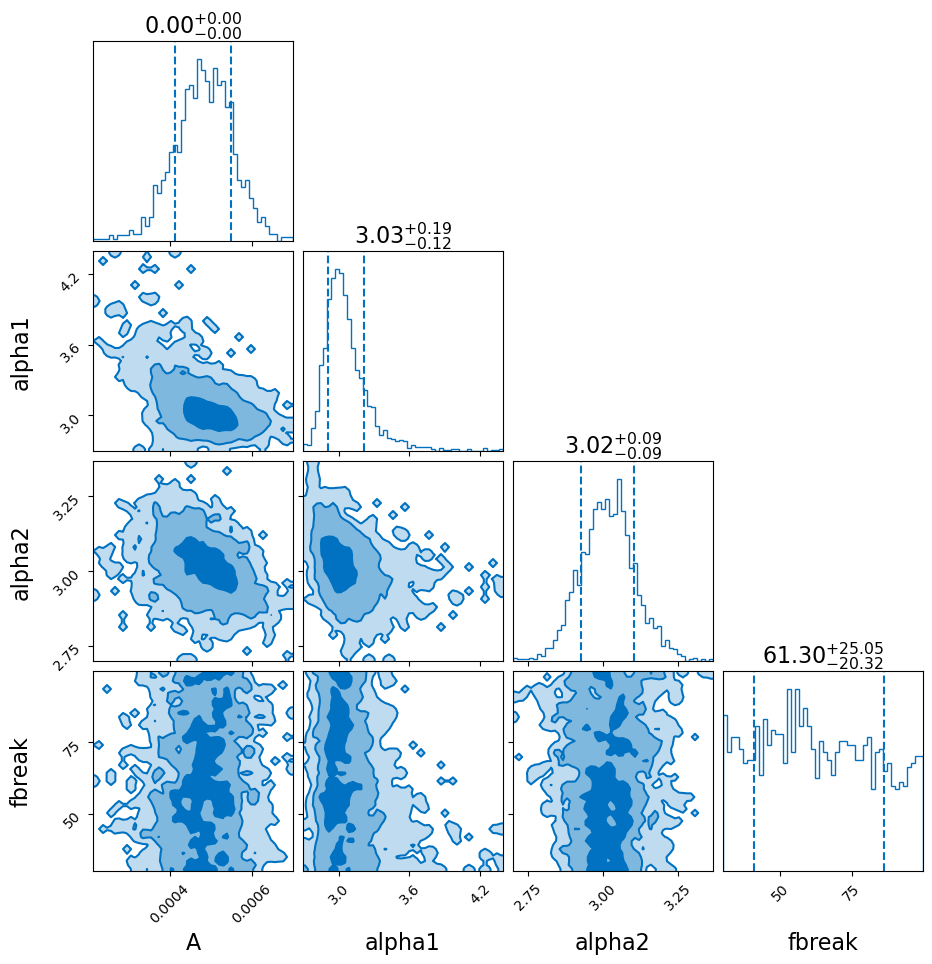

In [12]:
# A few simple setup steps
label = 'GWB_brokenpowerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax = 1e-10,1e-3
alpha1_min,alpha1_max=-5,5
alpha2_min,alpha2_max=-5,5
fbreak_min,fbreak_max=30,100
    

fref=25

baselines=[Baseline('test',Y_f[1:],var_f[1:],freqs[1:])]

likelihood = BrokenPowerLawGWBLikelihood(baselines,fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha1=bilby.core.prior.Uniform(alpha1_min,alpha1_max, 'alpha1'),
              alpha2=bilby.core.prior.Uniform(alpha2_min,alpha2_max, 'alpha2'),
              fbreak=bilby.core.prior.Uniform(fbreak_min,fbreak_max, 'fbreak'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()